# MCH–MFT Track Matching — Training & Testing

Learn-to-Rank (XGBoost LambdaRank) to score (MCH, MFT candidate) pairs.  
Each MCH track forms a **group** of up to 5 candidates; the model learns to rank the true match highest within each group.
The top-ranked candidate is accepted if its score exceeds a tunable threshold.

**Stages:**
1. Load data with hipe4ml
2. Feature engineering
3. Train/test split (by MCH track group)
4. XGBoost LambdaRank training
5. Group-level evaluation (efficiency, purity, MRR)

## 0. Imports

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import importlib
import Utils

from hipe4ml.tree_handler import TreeHandler
from sklearn.model_selection import GroupShuffleSplit

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 1. Load, Format, Engineer Data

In [26]:
df_original = Utils.get_dataframe("FwdMatchMLCandidatesFull.root")


Reading FwdMatchMLCandidatesFull.root:DF_2423890633315488/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633315296/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633272288/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633272096/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633229376/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633229216/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633186176/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633186016/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633057216/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633057056/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633014016/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890633013856/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890632970816/O2fwdmlcand;1
Reading FwdMatchMLCandidatesFull.root:DF_2423890632970656/O2fwdm

In [37]:
df =df_original.copy() 
importlib.reload(Utils)

<module 'Utils' from '/home/zinhle/Documents/ServiceTask/matching/Utils.py'>

In [38]:
df = Utils.perform_cuts(df)
df = Utils.design_features(df)

FEATURES = [f for f in df.columns.tolist() if f not in Utils.NON_TRAINING_FEATURES]

TARGET = "IsSignal"

GROUP  = "mchID"


[Eta window] -3.6 < eta_MCH < -2.45
Removed rows: 47  signal=3  background=44


/home/zinhle/Documents/ServiceTask/matching/Utils.py:76: RuntimeWarning: invalid value encountered in arccos
  df['DeltaDirection'] = np.arccos(


In [39]:
df[FEATURES].describe()

,XMCH,YMCH,PhiMCH,TanlMCH,InvQPtMCH,Chi2MCH,PDCA,Rabs,CXXMCH,CYYMCH,CPhiPhiMCH,CTglTglMCH,C1Pt1PtMCH,CXYMCH,CPhiYMCH,CPhiXMCH,CTglXMCH,CTglYMCH,CTglPhiMCH,C1PtXMCH,C1PtYMCH,C1PtPhiMCH,C1PtTglMCH,XMFT,YMFT,PhiMFT,TanlMFT,InvQPtMFT,Chi2MFT,CXXMFT,CYYMFT,CPhiPhiMFT,CTglTglMFT,C1Pt1PtMFT,CXYMFT,CPhiYMFT,CPhiXMFT,CTglXMFT,CTglYMFT,CTglPhiMFT,C1PtXMFT,C1PtYMFT,C1PtPhiMFT,C1PtTglMFT,DCAX,DCAY,IsAmbig,MFTMult,DeltaX,DeltaY,DeltaPhi,DeltaTanl,DeltaR,RelPtDiff,SameSign,PtMCH,PtMFT,DeltaPt,PullPt,PullX,PullY,PullR,PullPhi,PullTanl,DeltaDirection
count,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,4.445740e+05,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,4.445740e+05,4.445740e+05,4.445740e+05,4.445740e+05,4.445740e+05,4.445740e+05,4.445740e+05,4.445740e+05,444574.000000,4.445740e+05,4.445740e+05,4.445740e+05,4.445740e+05,4.445740e+05,4.445740e+05,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444574.000000,444543.000000
mean,-0.012059,-0.019278,-0.004594,-11.316836,0.000233,0.121687,60.916317,48.474800,5.098009,5.166817,0.005313,0.787335,0.002912,0.016995,-0.000070,-0.000628,-0.003513,0.002245,-1.279799e-07,0.000063,0.000865,0.000003,-0.000025,0.170229,-0.040665,0.000696,-10.593516,-0.046673,12.100259,6.596692e-03,2.366263e-02,3.145041e+00,6.336610e+00,3.831666e+07,1.154627e-02,1.089688e-01,2.412485e-01,0.166005,3.544175e-01,4.394091e+00,-4.124634e+02,-8.799453e+02,-1.090672e+04,-1.543111e+04,0.059743,-0.016750,0.039415,54.120191,-0.182288,0.021387,-0.002620,-0.723318,4.928349,0.503071,0.561072,2.441557,3.238662,-0.797106,-5.428627,-0.123707,0.021010,2.049980,-0.052441,-0.467207,0.043184
std,6.297547,6.196291,1.816594,3.390646,0.562161,0.146569,37.913239,15.288455,6.593628,6.581830,0.008876,1.828884,0.005790,0.015635,0.165295,0.176771,2.049274,1.916273,2.472042e-04,0.132923,0.124763,0.000058,0.104740,6.013183,6.150440,1.767696,5.043516,16.071112,261.843994,2.401328e+00,9.653102e+00,1.464923e+03,2.976346e+03,1.806476e+10,4.674077e+00,5.553504e+01,1.181202e+02,78.123085,1.666790e+02,2.071092e+03,1.940967e+05,4.141807e+05,5.143811e+06,7.275293e+06,26.404211,25.529221,0.194581,44.607496,4.657163,4.524333,0.609431,4.967265,4.231285,0.417098,0.496257,1.721488,338.975128,338.975891,1037.252686,3.126267,2.800807,2.097733,14.577782,7.534155,0.049631
min,-45.253906,-42.404964,-3.141582,-18.285234,-1.187235,0.004028,0.198184,17.608704,0.004668,0.071628,0.000009,0.000573,0.000031,-0.123969,-2.528492,-2.829464,-38.000622,-35.215347,-1.500593e-03,-2.096802,-1.708864,-0.000265,-2.225602,-16.511259,-18.638472,-3.141469,-162.371094,-4662.500000,0.016113,1.157314e-07,1.184465e-07,2.042110e-07,3.392383e-07,6.768926e-03,-1.943976e+01,-3.586423e+03,-4.300925e+03,-0.291367,-6.057841e-01,-3.368810e+02,-9.151099e+07,-1.952750e+08,-2.425171e+09,-3.430110e+09,-12212.385742,-10370.708984,0.000000,0.000000,-53.944206,-48.711956,-3.141137,-2407.367432,0.005405,-0.999971,0.000000,0.842293,0.000214,-202170.265625,-553922.125000,-123.942459,-53.156834,0.002829,-405.680328,-193.028641,0.000000
25%,-4.529028,-4.445957,-1.584483,-14.013054,-0.483877,0.067383,35.250610,35.732727,1.367454,1.446005,0.001414,0.145202,0.000329,0.002766,-0.047249,-0.049972,-0.535752,-0.533533,-1.061336e-04,-0.022832,-0.021250,-0.000028,-0.015432,-4.708739,-4.977214,-1.524169,-13.001709,-2.172852,3.140625,2.584092e-05,2.686759e-05,8.465006e-06,1.795301e-04,3.931085e-01,-1.093459e-05,-2.977754e-05,-2.496742e-05,-0.000088,-1.183881e-04,-1.567620e-06,-3.825914e-03,-3.630879e-03,-1.304472e-

In [40]:
FEATURES

['XMCH',
 'YMCH',
 'PhiMCH',
 'TanlMCH',
 'InvQPtMCH',
 'Chi2MCH',
 'PDCA',
 'Rabs',
 'CXXMCH',
 'CYYMCH',
 'CPhiPhiMCH',
 'CTglTglMCH',
 'C1Pt1PtMCH',
 'CXYMCH',
 'CPhiYMCH',
 'CPhiXMCH',
 'CTglXMCH',
 'CTglYMCH',
 'CTglPhiMCH',
 'C1PtXMCH',
 'C1PtYMCH',
 'C1PtPhiMCH',
 'C1PtTglMCH',
 'XMFT',
 'YMFT',
 'PhiMFT',
 'TanlMFT',
 'InvQPtMFT',
 'Chi2MFT',
 'CXXMFT',
 'CYYMFT',
 'CPhiPhiMFT',
 'CTglTglMFT',
 'C1Pt1PtMFT',
 'CXYMFT',
 'CPhiYMFT',
 'CPhiXMFT',
 'CTglXMFT',
 'CTglYMFT',
 'CTglPhiMFT',
 'C1PtXMFT',
 'C1PtYMFT',
 'C1PtPhiMFT',
 'C1PtTglMFT',
 'DCAX',
 'DCAY',
 'IsAmbig',
 'MFTMult',
 'DeltaX',
 'DeltaY',
 'DeltaPhi',
 'DeltaTanl',
 'DeltaR',
 'RelPtDiff',
 'SameSign',
 'PtMCH',
 'PtMFT',
 'DeltaPt',
 'PullPt',
 'PullX',
 'PullY',
 'PullR',
 'PullPhi',
 'PullTanl',
 'DeltaDirection']

## 2. Sanity Checks

In [41]:
n_mch_tracks = df["mchID"].nunique()
n_positive = df["IsSignal"].sum()
candidates_per_track = df.groupby("mchID").size()

print(f"MCH tracks:          {n_mch_tracks:,}")
print(f"Total pairs:         {len(df):,}")
print(f"True matches:        {int(n_positive):,} ({100*n_positive/len(df):.1f}%)")
print(f"Candidates per track: min={candidates_per_track.min()}, "
      f"max={candidates_per_track.max()}, "
      f"mean={candidates_per_track.mean():.2f}")

# Tracks with no true match among candidates
tracks_with_match = df.groupby("mchID")["IsSignal"].max()
n_no_match = (tracks_with_match == 0).sum()
print(f"Tracks with no true match in candidates: {n_no_match:,} "
      f"({100*n_no_match/n_mch_tracks:.1f}%)")

MCH tracks:          90,027
Total pairs:         444,574
True matches:        64,842 (14.6%)
Candidates per track: min=1, max=5, mean=4.94
Tracks with no true match in candidates: 25,225 (28.0%)


## 4. Train / Test Split

Split is done **by MCH track group**, not by row, to avoid data leakage  
(candidates from the same MCH track must not appear in both train and test).

In [42]:

groups = df[GROUP].values

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=groups))

df_train = df.iloc[train_idx].copy()
df_test  = df.iloc[test_idx].copy()

# Sort by group — required by XGBRanker
df_train = df_train.sort_values(GROUP).reset_index(drop=True)
df_test  = df_test.sort_values(GROUP).reset_index(drop=True)

X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_test,  y_test  = df_test[FEATURES],  df_test[TARGET]

# Group size arrays: number of candidates per MCH track, in order
# XGBRanker needs to know which rows belong to the same query
train_groups = df_train.groupby(GROUP, sort=False).size().values
test_groups  = df_test.groupby(GROUP, sort=False).size().values

print(f"Train: {len(df_train):,} pairs ({df_train[GROUP].nunique():,} MCH tracks)")
print(f"Test:  {len(df_test):,} pairs ({df_test[GROUP].nunique():,} MCH tracks)")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")

Train: 355,656 pairs (72,021 MCH tracks)
Test:  88,918 pairs (18,006 MCH tracks)
Train positive rate: 0.146
Test  positive rate: 0.145


## 5. Train XGBoost LambdaRank

`objective='rank:ndcg'` optimises the ranking within each group of candidates directly,  
avoiding the class-imbalance problem of a binary classifier and matching the problem structure exactly.  

In [43]:
model = xgb.XGBRanker(
    objective="rank:ndcg",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="ndcg",
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_test, y_test)],
    eval_group=[test_groups],
    verbose=50,
)

print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-ndcg:0.97812
[50]	validation_0-ndcg:0.99510
[100]	validation_0-ndcg:0.99663
[150]	validation_0-ndcg:0.99730
[200]	validation_0-ndcg:0.99756
[235]	validation_0-ndcg:0.99765

Best iteration: 215


## 6. Feature Importance

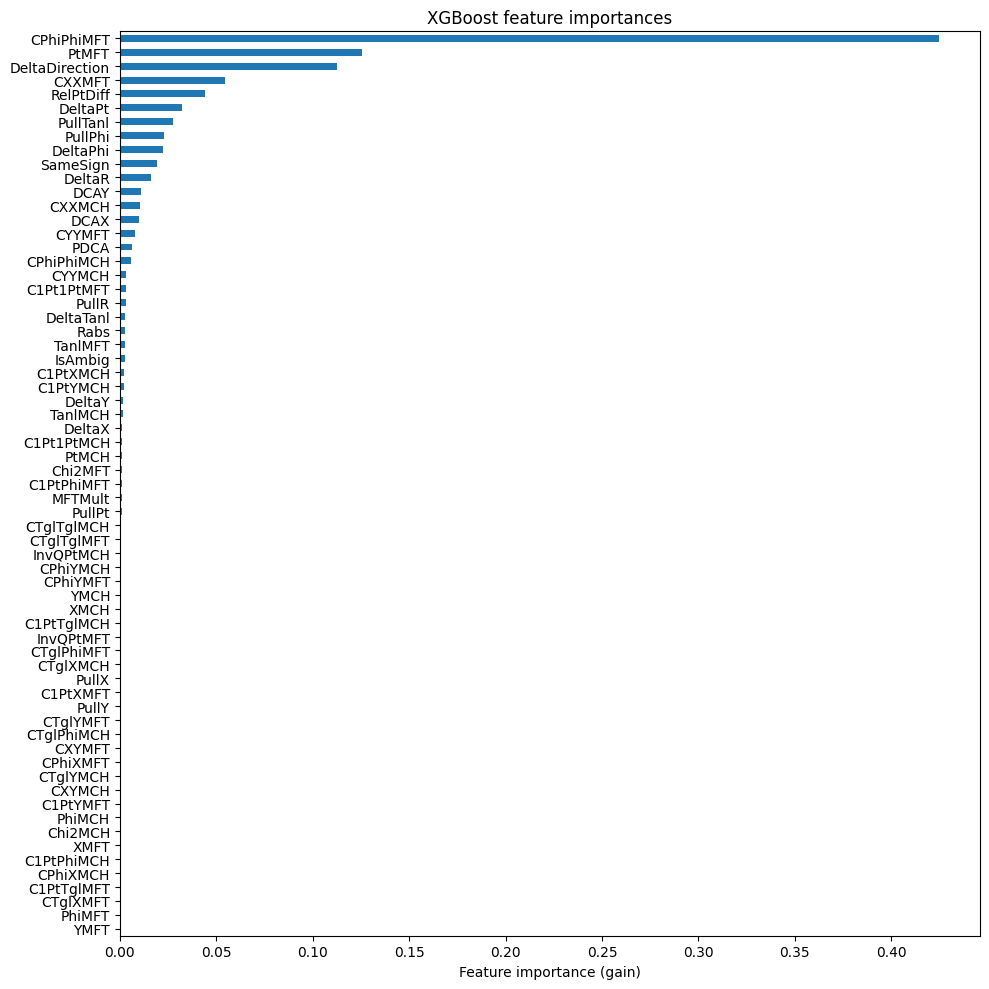

In [44]:
importances = pd.Series(
    model.feature_importances_, index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
importances.plot.barh(ax=ax)
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGBoost feature importances")
plt.tight_layout()
plt.show()

## 7. Group-Level Evaluation

Metrics are computed at the **MCH track level**, not the pair level:

- **Efficiency**: fraction of tracks where the top-scored candidate is the true match  
- **Purity**: fraction of *accepted* matches that are correct (varies with threshold)  
- **MRR**: Mean Reciprocal Rank — comparable to the Ejima et al. result  
- **Purity–efficiency curve**: sweep the score threshold

In [45]:
df_test = df_test.copy()
df_test["score"] = model.predict(X_test)


def build_group_summary(df_eval: pd.DataFrame) -> pd.DataFrame:
    """
    Vectorised: for each MCH track group, find the top-scored candidate
    and the rank of the true match. Returns one row per group.
    """
    # Score rank within group (1 = highest score)
    df_eval = df_eval.copy()
    df_eval["score_rank"] = (
        df_eval.groupby(GROUP)["score"]
        .rank(ascending=False, method="first")
        .astype(int)
    )

    # Top-scored candidate per group
    top = df_eval[df_eval["score_rank"] == 1][[GROUP, "score", TARGET]].copy()
    top.columns = [GROUP, "top_score", "top_correct"]

    # Rank of the true match per group (NaN if no true match in group)
    true_match_rank = (
        df_eval[df_eval[TARGET] == 1]
        .set_index(GROUP)["score_rank"]
        .rename("true_rank")
    )

    # Whether any true match exists in the group
    has_match = df_eval.groupby(GROUP)[TARGET].max().rename("has_match")

    summary = (
        top.set_index(GROUP)
        .join(true_match_rank)
        .join(has_match)
        .reset_index()
    )
    return summary


def compute_group_metrics(summary: pd.DataFrame,
                          threshold: float) -> dict:
    """
    Given the pre-computed group summary, apply a score threshold and
    return efficiency, purity, MRR, and acceptance rate.
    """
    accepted  = summary[summary["top_score"] >= threshold]
    matchable = summary[summary["has_match"] == 1]

    efficiency = matchable["top_correct"].mean() if len(matchable) else 0.0
    purity     = accepted["top_correct"].mean()  if len(accepted)  else 0.0

    rr = 1.0 / matchable["true_rank"].dropna()
    mrr = rr.mean() if len(rr) else 0.0

    return {
        "True efficiency":       efficiency, # internally efficiency, in our nomenclature, is the fraction of matchable tracks that are correctly identified as such by the top candidate passing the threshold - True Eff
        "purity":           purity,          # internally purity, in our nomenclature, it is the fraction of accepted tracks that are correctly assigned to their true match among all accepted tracks purity
        "mrr":              mrr,
        "n_accepted":       len(accepted),
        "n_total":          len(summary),
        "acceptance_rate":  len(accepted) / len(summary) if len(summary) else 0.0,
    }


# Build summary once; reuse for all threshold sweeps
summary = build_group_summary(df_test)

# Pick a sensible default threshold: median of top-candidate scores
default_threshold = 0 #float(summary["top_score"].median())
print(f"Score range (top candidates): "
      f"[{summary['top_score'].min():.3f}, {summary['top_score'].max():.3f}]")
print(f"Default threshold (median):    {default_threshold:.3f}")

metrics = compute_group_metrics(summary, threshold=default_threshold)
print(f"\n=== Group-level metrics (threshold={default_threshold:.3f}) ===")
for k, v in metrics.items():
    print(f"  {k:20s}: {v:.4f}" if isinstance(v, float) else f"  {k:20s}: {v}")

Score range (top candidates): [-5.834, 3.777]
Default threshold (median):    0.000

=== Group-level metrics (threshold=0.000) ===
  True efficiency     : 0.9917
  purity              : 0.8199
  mrr                 : 0.9952
  n_accepted          : 15491
  n_total             : 18016
  acceptance_rate     : 0.8598


In [46]:
g = xgb.to_graphviz(
    model,
    num_trees=10,
    graph_attr={"dpi": "300", "size": "20,10"}
)

g.render("xgb_tree", format="png", cleanup=True)

/home/zinhle/.local/lib/python3.10/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


'xgb_tree.png'

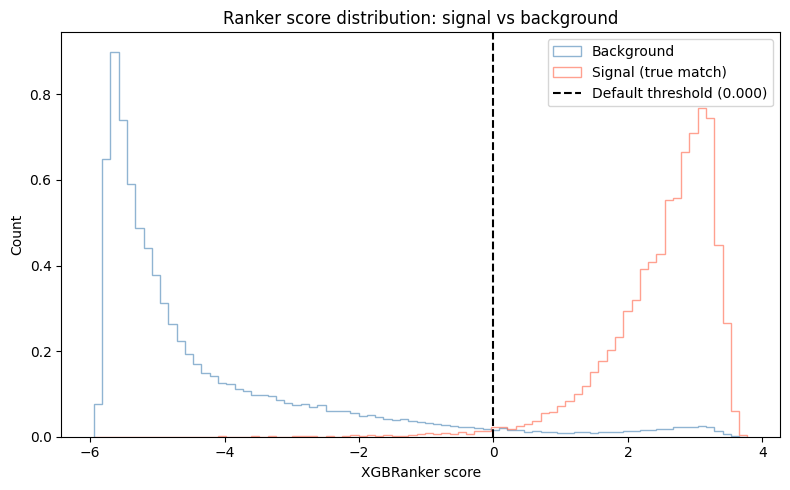

In [47]:
dense = True
sig = df_test[df_test[TARGET] == 1]["score"]
bkg = df_test[df_test[TARGET] == 0]["score"]

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(df_test["score"].min(), df_test["score"].max(), 80)

ax.hist(bkg, bins=bins, density=dense, alpha=0.6, color="steelblue",histtype='step', label="Background")
ax.hist(sig, bins=bins, density=dense, alpha=0.6, color="tomato",histtype='step',    label="Signal (true match)")

ax.axvline(default_threshold, color="black", linestyle="--", lw=1.5,
           label=f"Default threshold ({default_threshold:.3f})")

ax.set_xlabel("XGBRanker score")
ax.set_ylabel("Count")
ax.set_title("Ranker score distribution: signal vs background")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Purity–Efficiency Curve

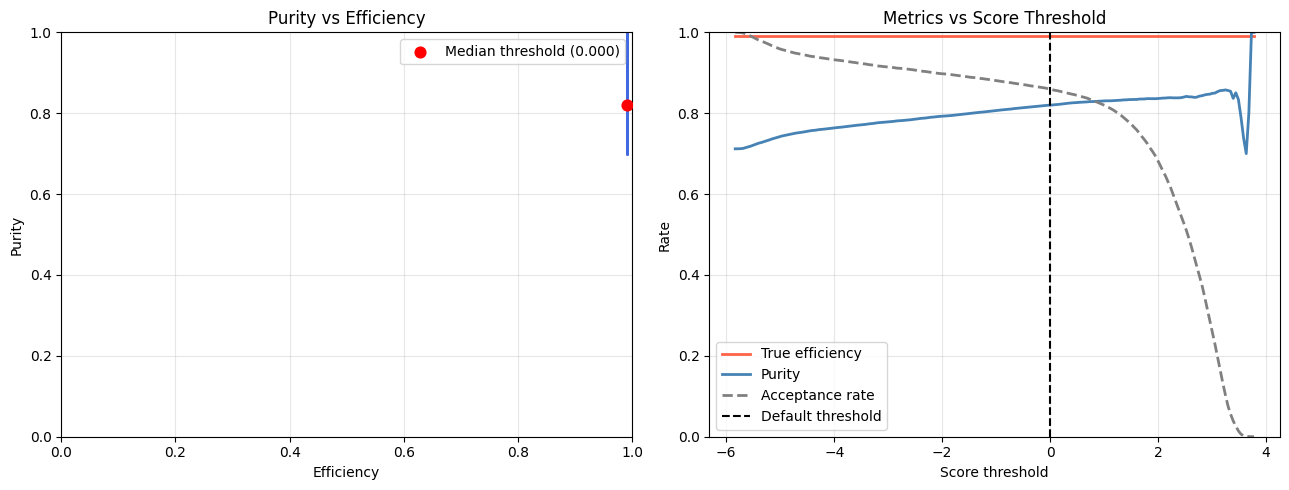

MRR (no threshold): 0.9952


In [48]:
# Sweep over the actual score range of top candidates
score_min = summary["top_score"].min()
score_max = summary["top_score"].max()
thresholds = np.linspace(score_min, score_max, 200)

records = [compute_group_metrics(summary, t) | {"threshold": t} for t in thresholds]
curve   = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: purity vs efficiency
ax = axes[0]
ax.plot(curve["True efficiency"], curve["purity"], lw=2, color="royalblue")
m_def = compute_group_metrics(summary, default_threshold)
ax.scatter(m_def["True efficiency"], m_def["purity"],
           color="red", zorder=5, s=60,
           label=f"Median threshold ({default_threshold:.3f})")
ax.set_xlabel("Efficiency")
ax.set_ylabel("Purity")
ax.set_title("Purity vs Efficiency")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()

# Right: both vs threshold
ax = axes[1]
ax.plot(curve["threshold"], curve["True efficiency"],
        lw=2, color="tomato",     label="True efficiency")
ax.plot(curve["threshold"], curve["purity"],
        lw=2, color="steelblue",  label="Purity")
ax.plot(curve["threshold"], curve["acceptance_rate"],
        lw=2, color="grey", linestyle="--", label="Acceptance rate")
ax.axvline(default_threshold, color="black", linestyle="--", lw=1.5,
           label=f"Default threshold")
ax.set_xlabel("Score threshold")
ax.set_ylabel("Rate")
ax.set_title("Metrics vs Score Threshold")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"MRR (no threshold): {compute_group_metrics(summary, score_min)['mrr']:.4f}")

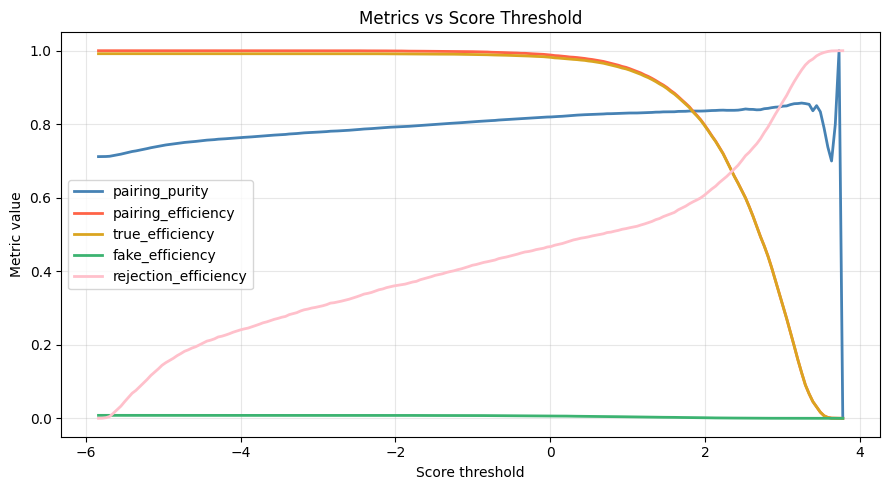

In [49]:

def sweep_threshold_plot(df_eval, summary, compute_metrics_fn, 
                         score_col="top_score", n_steps=200, title="Metrics vs Threshold"):
    """
    Sweeps a threshold over the range of top candidate scores,
    calls compute_metrics_fn(df_eval, summary, threshold) at each step,
    and plots the 4 returned metrics in different colours.
    
    compute_metrics_fn should return a tuple of (metric1, metric2, metric3, metric4)
    and accept (df_eval, summary, threshold) as arguments.
    Adjust the signature to match your actual function.
    """
    score_min = summary[score_col].min()
    score_max = summary[score_col].max()
    thresholds = np.linspace(score_min, score_max, n_steps)
    
    results = [compute_metrics_fn(df_eval, t) for t in thresholds]
    m1, m2, m3, m4, m5 = zip(*results)
    
    colours = ["steelblue", "tomato", "goldenrod", "mediumseagreen", "pink"]
    # Update these labels to match what your function actually returns
    labels  = ["pairing_purity", "pairing_efficiency", "true_efficiency", "fake_efficiency", "rejection_efficiency"]
    metrics = [m1, m2, m3, m4, m5]
    
    fig, ax = plt.subplots(figsize=(9, 5))
    for vals, label, colour in zip(metrics, labels, colours):
        ax.plot(thresholds, vals, lw=2, label=label, color=colour)
    
    ax.set_xlabel("Score threshold")
    ax.set_ylabel("Metric value")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

sweep_threshold_plot(df_test, summary, Utils.inhousemetrics, title="Metrics vs Score Threshold")

## Misranking Analysis --- to be HEAVILY modified - include those with no match
We label each MCH track group as **correct** (true match is top-ranked) or **misranked** (true match exists but was not top-ranked).  
Groups with no true match among candidates are excluded from this analysis.

In [50]:
# Build full outcome labels across all groups
full_analysis = summary.copy()
full_analysis["outcome"] = np.where(
    full_analysis["has_match"] == 0, "No match",
    np.where(full_analysis["top_correct"] == 1, "Correct", "Misranked")
)

counts = full_analysis["outcome"].value_counts()
total  = len(full_analysis)
for outcome in ["Correct", "Misranked", "No match"]:
    n = counts.get(outcome, 0)
    print(f"{outcome:12s}: {n:,}  ({100*n/total:.2f}%)")

# Restrict to groups with a true match for the margin/scatter/kinematic plots
analysis = full_analysis[full_analysis["has_match"] == 1].copy()

# True match score per group
true_scores = (
    df_test[df_test[TARGET] == 1]
    .groupby(GROUP)["score"].first()
    .rename("true_score")
)
# Second-highest score per group
second_scores = (
    df_test.groupby(GROUP)["score"]
    .apply(lambda s: s.nlargest(2).iloc[-1])
    .rename("second_score")
)

analysis = analysis.set_index(GROUP).join(true_scores).join(second_scores).reset_index()
analysis["score_margin"] = analysis["top_score"] - analysis["second_score"]

Correct     : 12,826  (71.19%)
Misranked   : 107  (0.59%)
No match    : 5,083  (28.21%)


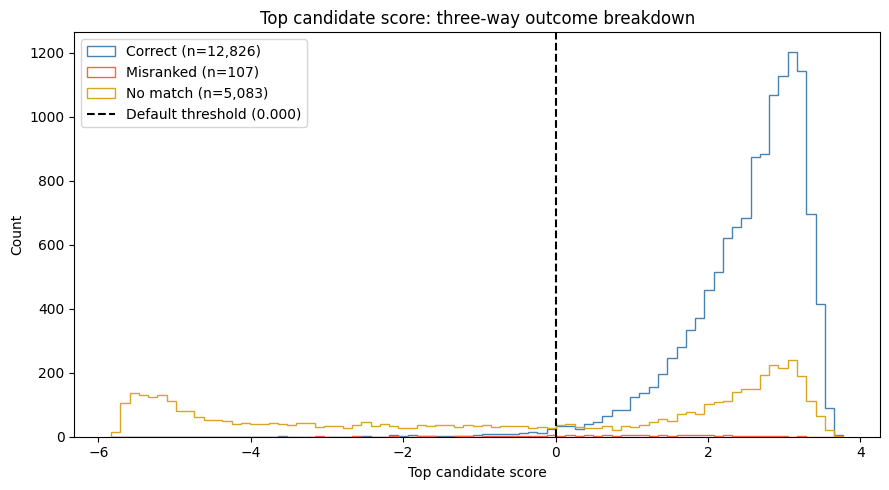

In [51]:
# --- Plot 1: Three-way top candidate score distribution ---
# Key diagnostic: can the threshold separate no-match groups from real matches?
palette = {"Correct": "steelblue", "Misranked": "tomato", "No match": "goldenrod"}
score_min_all = full_analysis["top_score"].min()
score_max_all = full_analysis["top_score"].max()
bins = np.linspace(score_min_all, score_max_all, 80)

fig, ax = plt.subplots(figsize=(9, 5))
for outcome in ["Correct", "Misranked", "No match"]:
    sub = full_analysis[full_analysis["outcome"] == outcome]["top_score"]
    ax.hist(sub, bins=bins, density=False,histtype='step',
            color=palette[outcome], label=f"{outcome} (n={len(sub):,})")

ax.axvline(default_threshold, color="black", linestyle="--", lw=1.5,
           label=f"Default threshold ({default_threshold:.3f})")
ax.set_xlabel("Top candidate score")
ax.set_ylabel("Count")
ax.set_title("Top candidate score: three-way outcome breakdown")
ax.legend()
plt.tight_layout()
plt.show()

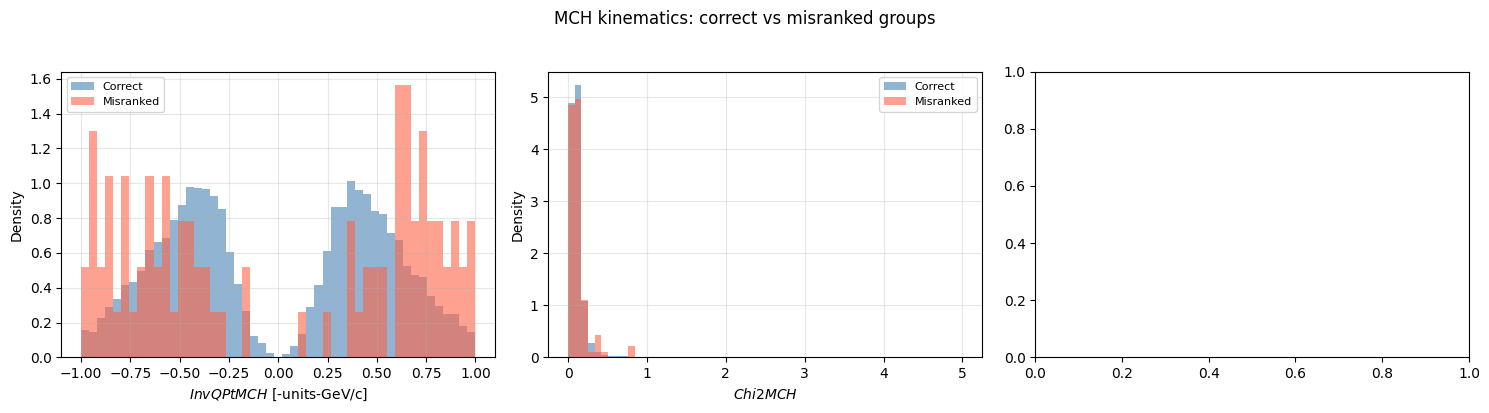

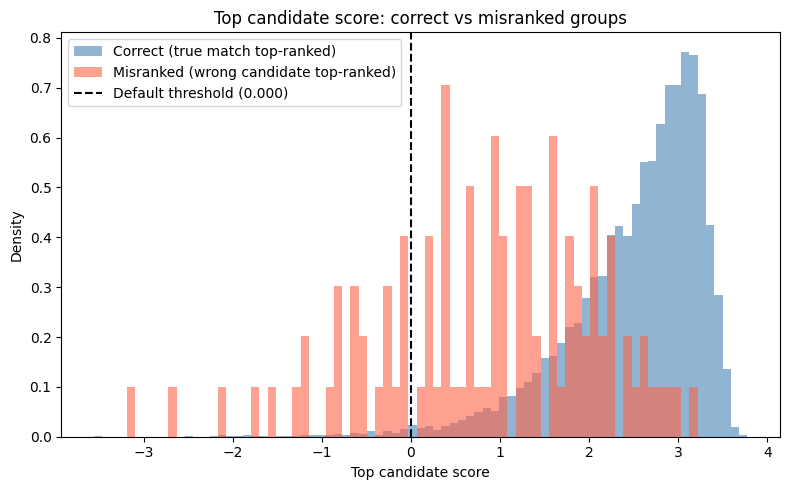

In [52]:
# --- Plot 1: Top candidate score split by outcome ---
correct_scores   = analysis[analysis["outcome"] == "Correct"]["top_score"]
misranked_scores = analysis[analysis["outcome"] == "Misranked"]["top_score"]
# --- Plot 4: Kinematic distributions of the MCH track --- correct vs misranked
# Reveals if failures are concentrated in specific regions of phase space
true_kinematics = (
    df_test[df_test[TARGET] == 1]
    [[GROUP, "InvQPtMCH", "Chi2MCH"]]
    .drop_duplicates(subset=GROUP)
    .set_index(GROUP)
)
analysis_kin = analysis.set_index(GROUP).join(true_kinematics).reset_index()

kin_vars = {
    "InvQPtMCH":   (r"$InvQPtMCH$ [-units-GeV/c]",  np.linspace(-1,  1, 50)),
    "Chi2MCH": (r"$Chi2MCH$",        np.linspace(0, 5, 60)),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (var, (label, bins)) in zip(axes, kin_vars.items()):
    for outcome, colour in [("Correct", "steelblue"), ("Misranked", "tomato")]:
        sub = analysis_kin[analysis_kin["outcome"] == outcome]
        ax.hist(sub[var].dropna(), bins=bins, density=True,
                alpha=0.6, color=colour, label=outcome)
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("MCH kinematics: correct vs misranked groups", y=1.02)
plt.tight_layout()
plt.show()
bins = np.linspace(analysis["top_score"].min(), analysis["top_score"].max(), 80)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(correct_scores,   bins=bins, density=True, alpha=0.6,
        color="steelblue", label="Correct (true match top-ranked)")
ax.hist(misranked_scores, bins=bins, density=True, alpha=0.6,
        color="tomato",    label="Misranked (wrong candidate top-ranked)")
ax.axvline(default_threshold, color="black", linestyle="--", lw=1.5,
           label=f"Default threshold ({default_threshold:.3f})")
ax.set_xlabel("Top candidate score")
ax.set_ylabel("Density")
ax.set_title("Top candidate score: correct vs misranked groups")
ax.legend()
plt.tight_layout()
plt.show()

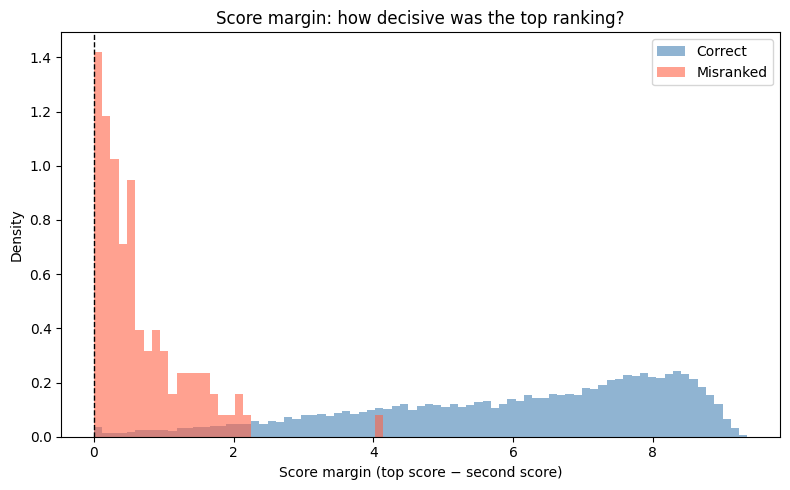

In [53]:
# --- Plot 2: Score margin (top - second) split by outcome ---
# Large margin = confident decision; near-zero = top two were almost tied
bins_m = np.linspace(analysis["score_margin"].min(), analysis["score_margin"].max(), 80)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(analysis[analysis["outcome"] == "Correct"]["score_margin"],
        bins=bins_m, density=True, alpha=0.6,
        color="steelblue", label="Correct")
ax.hist(analysis[analysis["outcome"] == "Misranked"]["score_margin"],
        bins=bins_m, density=True, alpha=0.6,
        color="tomato",    label="Misranked")
ax.axvline(0, color="black", linestyle="--", lw=1)
ax.set_xlabel("Score margin (top score − second score)")
ax.set_ylabel("Density")
ax.set_title("Score margin: how decisive was the top ranking?")
ax.legend()
plt.tight_layout()
plt.show()

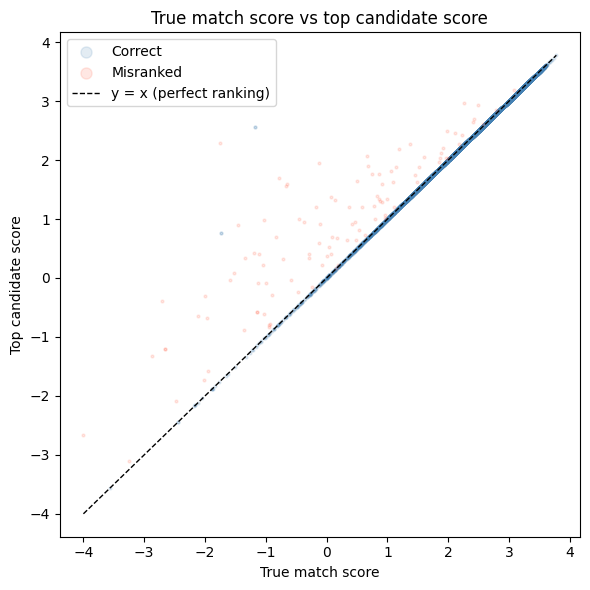

In [54]:
# --- Plot 3: True match score vs top candidate score (scatter) ---
# Points on the diagonal = true match was top-ranked
# Points below diagonal  = a wrong candidate outscored the true match
fig, ax = plt.subplots(figsize=(6, 6))

for outcome, colour in [("Correct", "steelblue"), ("Misranked", "tomato")]:
    sub = analysis[analysis["outcome"] == outcome]
    ax.scatter(sub["true_score"], sub["top_score"],
               alpha=0.15, s=4, color=colour, label=outcome, rasterized=True)

lims = [analysis[["true_score", "top_score"]].min().min(),
        analysis[["true_score", "top_score"]].max().max()]
ax.plot(lims, lims, "k--", lw=1, label="y = x (perfect ranking)")
ax.set_xlabel("True match score")
ax.set_ylabel("Top candidate score")
ax.set_title("True match score vs top candidate score")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()